<a href="https://colab.research.google.com/github/LeonardooAlves/WM9G1-BDAI/blob/main/Week%202/2_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression: From Preprocessing to Hyperparameter Tuning
**MSc Engineering Business Management — Big Data Analytics for Industry**

In this notebook we will work through a **complete classification pipeline** using the UCI Bank Marketing dataset. A Portuguese bank ran telephone campaigns to convince clients to subscribe to a term deposit. Our job is to predict whether a client will subscribe (`yes`) or not (`no`).

**What we will cover:**
1. Loading and exploring the data (EDA)
2. Preprocessing for machine learning
3. Building a baseline Logistic Regression model
4. Evaluating the model with multiple metrics
5. Hyperparameter tuning with Grid Search
6. Optimising the decision threshold

## 1. Setup and Data Loading

First, let's install the UCI repository package and import the libraries we need.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 25)

print('Libraries loaded successfully')

Libraries loaded successfully


In [2]:
# Load the dataset from Google Cloud Storage
file_name = "banking.csv"
df = pd.read_csv(file_name)
print("Loaded:", df.shape)

# ── Separate features (X) and target (y) ──
# The target column 'y' is already encoded as 0/1 in this CSV
y = df['y']
X = df.drop(columns=['y'])

print(f'Features (X): {X.shape}')
print(f'Target (y):   {y.shape}  — already encoded as 0 and 1')
df.head()

Loaded: (41188, 21)
Features (X): (41188, 20)
Target (y):   (41188,)  — already encoded as 0 and 1


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,210,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,138,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,339,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,185,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,137,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1


## 2. Exploratory Data Analysis (EDA)

### 2.1 First Look at the Data

In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null 

In [4]:
# Summary statistics for numeric columns
df.describe()

,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911,0.112654
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528,0.316173
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


In [5]:
# Check for missing values
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


### 2.2 Target Variable Distribution

Before modelling, we need to understand our target variable. Is the dataset **balanced** or **imbalanced**? This will affect which evaluation metrics we should use.

In [6]:
# Count of each class
print(y.value_counts())
print()
print('Proportions:')
print(y.value_counts(normalize=True).round(3))

y
0    36548
1     4640
Name: count, dtype: int64

Proportions:
y
0    0.887
1    0.113
Name: proportion, dtype: float64


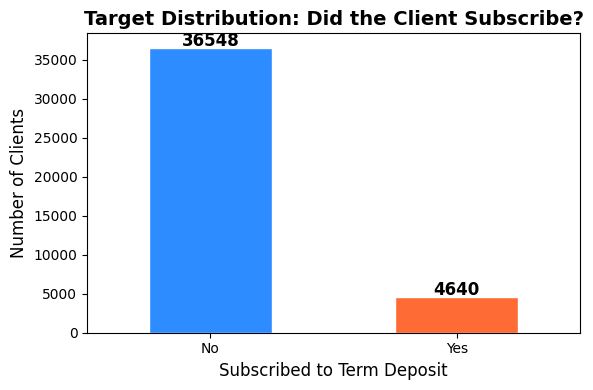

The dataset is IMBALANCED — roughly 89% "no" vs 11% "yes".
This means accuracy alone will be misleading!


In [8]:
# Visualise the class distribution
fig, ax = plt.subplots(figsize=(6, 4))

colours = ['#2D8CFF', '#FF6B35']
y.value_counts().plot(kind='bar', color=colours, edgecolor='white', ax=ax)

ax.set_title('Target Distribution: Did the Client Subscribe?', fontsize=14, fontweight='bold')
ax.set_xlabel('Subscribed to Term Deposit', fontsize=12)
ax.set_ylabel('Number of Clients', fontsize=12)
ax.set_xticklabels(['No', 'Yes'], rotation=0)

# Add count labels on bars
for i, v in enumerate(y.value_counts()):
    ax.text(i, v + 200, str(v), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print('The dataset is IMBALANCED — roughly 89% "no" vs 11% "yes".')
print('This means accuracy alone will be misleading!')

### 2.3 Feature Overview

In [9]:
# Identify column types from the FEATURES only (not including target)
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Numeric features ({len(numeric_cols)}):    {numeric_cols}')
print(f'Categorical features ({len(categorical_cols)}): {categorical_cols}')

Numeric features (10):    ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed']
Categorical features (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


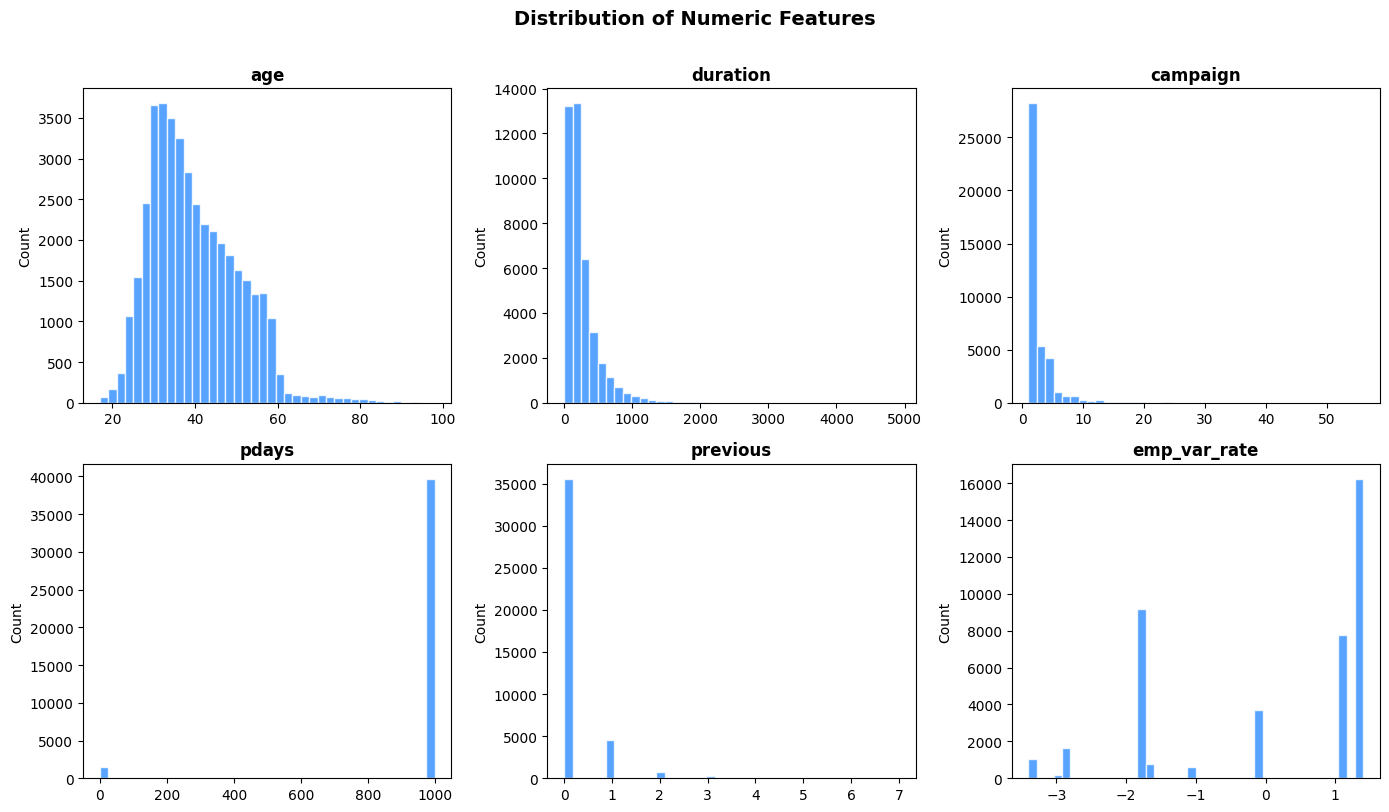

In [10]:
# Distribution of key numeric features
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

plot_cols = ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp_var_rate']

for i, col in enumerate(plot_cols):
    row, col_idx = i // 3, i % 3
    axes[row, col_idx].hist(df[col], bins=40, color='#2D8CFF', edgecolor='white', alpha=0.8)
    axes[row, col_idx].set_title(col, fontsize=12, fontweight='bold')
    axes[row, col_idx].set_ylabel('Count')

plt.suptitle('Distribution of Numeric Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

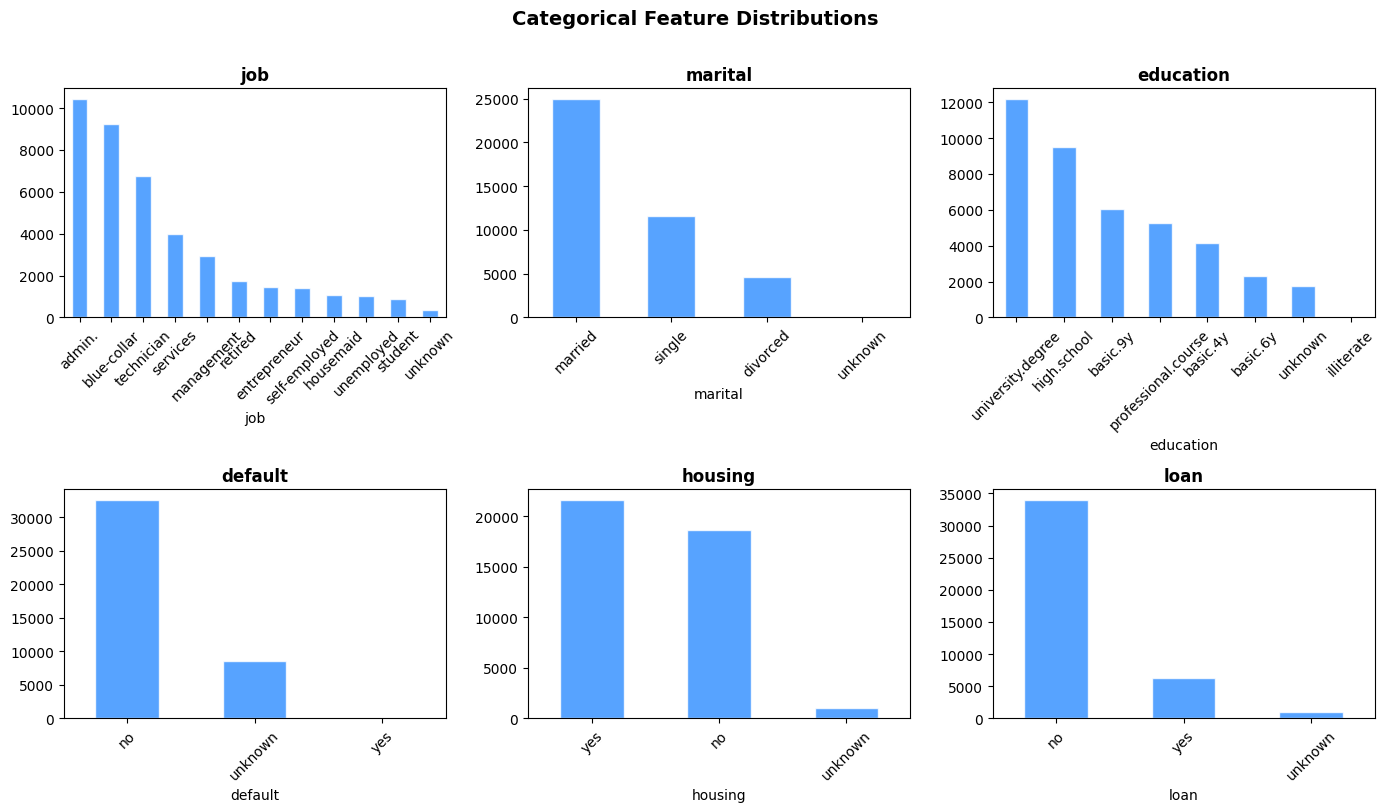

In [11]:
# Look at categorical features
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

cat_to_plot = ['job', 'marital', 'education', 'default', 'housing', 'loan']

for i, col in enumerate(cat_to_plot):
    row, col_idx = i // 3, i % 3
    df[col].value_counts().plot(kind='bar', ax=axes[row, col_idx],
                                 color='#2D8CFF', edgecolor='white', alpha=0.8)
    axes[row, col_idx].set_title(col, fontsize=12, fontweight='bold')
    axes[row, col_idx].tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [12]:
#check Education
df["education"].unique()

array(['basic.4y', 'unknown', 'university.degree', 'high.school',
       'basic.9y', 'professional.course', 'basic.6y', 'illiterate'],
      dtype=object)

In [13]:
# Only run this if the column exists
df["education"] = df["education"].replace(
        {"basic.4y": "Basic", "basic.6y": "Basic", "basic.9y": "Basic"}
)
print("Education categories after grouping:")
print(df["education"].value_counts().head(6))

Education categories after grouping:
education
Basic                  12513
university.degree      12168
high.school             9515
professional.course     5243
unknown                 1731
illiterate                18
Name: count, dtype: int64


### 2.4 Relationship with the Target

In [14]:
# Mean of numeric features grouped by target
numeric_cols_for_groupby = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
grouped = df[numeric_cols_for_groupby + ['y']].groupby('y').mean()
grouped

,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed
y,,,,,,,,,,
0,39.911185,220.844807,2.633085,984.113878,0.132374,0.248875,93.603757,-40.593097,3.811491,5176.166600
1,40.913147,553.191164,2.051724,792.035560,0.492672,-1.233448,93.354386,-39.789784,2.123135,5095.115991


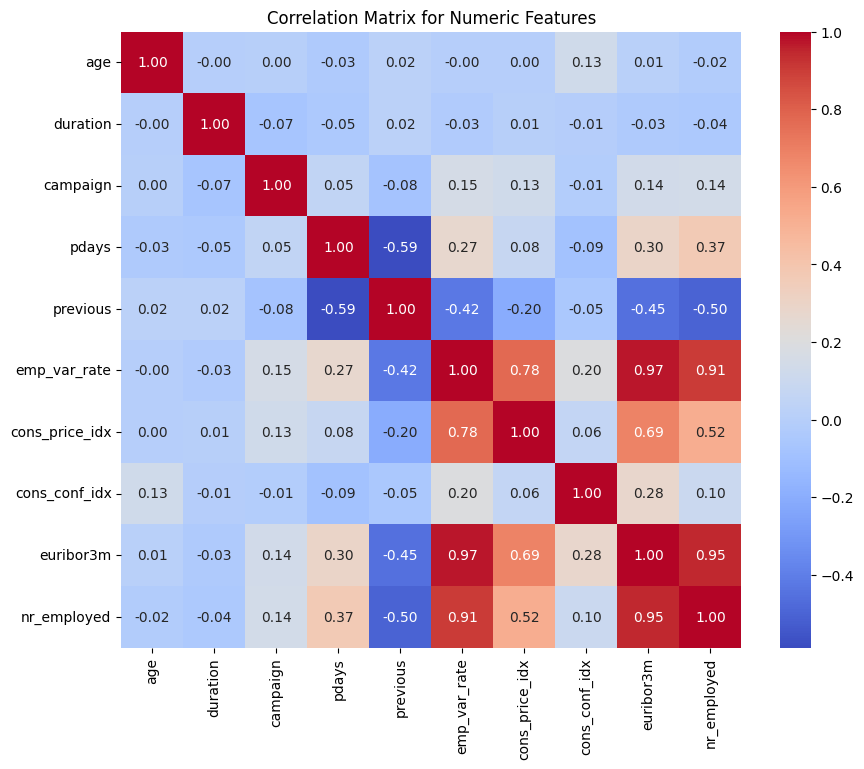

In [15]:
# Calculate the correlation matrix for numeric features
corr_matrix = X[numeric_cols].corr()

# Plotting the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlation Matrix for Numeric Features')
plt.show()

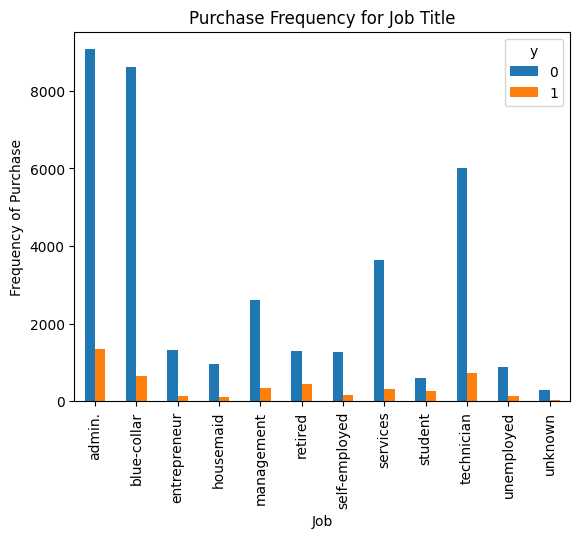

In [16]:
pd.crosstab(df.job,df.y).plot(kind='bar')
plt.title('Purchase Frequency for Job Title')
plt.xlabel('Job')
plt.ylabel('Frequency of Purchase')
plt.savefig('purchase_fre_job')

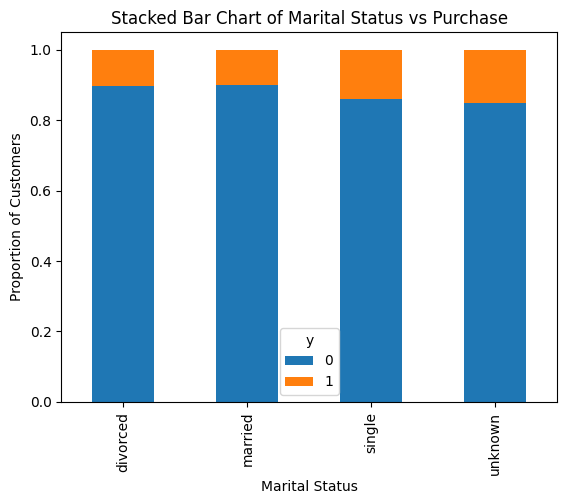

In [17]:
table=pd.crosstab(df.marital,df.y)
table.div(table.sum(1).astype(float), axis=0).plot(kind='bar', stacked=True)
plt.title('Stacked Bar Chart of Marital Status vs Purchase')
plt.xlabel('Marital Status')
plt.ylabel('Proportion of Customers')
plt.savefig('mariral_vs_pur_stack')

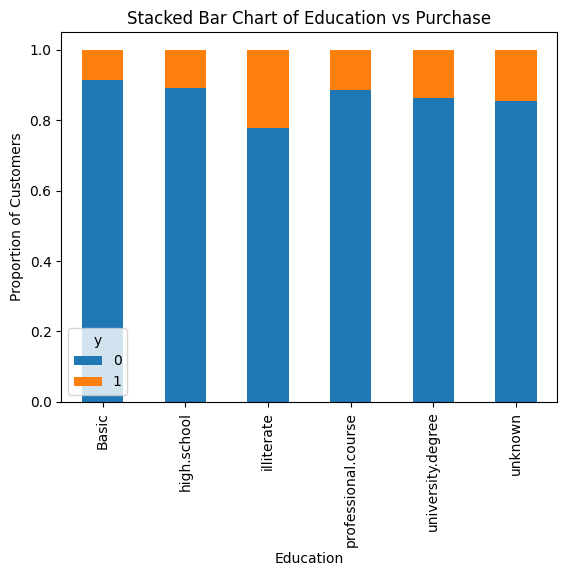

In [18]:
table=pd.crosstab(df.education,df.y)
table.div(table.sum(1).astype(float), axis=0).plot(kind='bar', stacked=True)
plt.title('Stacked Bar Chart of Education vs Purchase')
plt.xlabel('Education')
plt.ylabel('Proportion of Customers')
plt.savefig('edu_vs_pur_stack')

## 3. Data Preprocessing

Logistic regression requires **numeric input**. We need to:
1. Encode the target variable (`yes`/`no` → 1/0)
2. Encode categorical features (using one-hot encoding)
3. Scale numeric features (so regularisation treats all features fairly)
4. Split the data into training and test sets

### 3.1 Encode the Target Variable

In [19]:
# The target 'y' is already encoded as 0/1 in banking.csv,
# so no mapping is needed. We just assign it directly.
y_encoded = y.copy()

print('Target encoding:')
print(y_encoded.value_counts())
print(f'\nPositive class (subscribed): {y_encoded.sum()} ({y_encoded.mean():.1%})')

Target encoding:
y
0    36548
1     4640
Name: count, dtype: int64

Positive class (subscribed): 4640 (11.3%)


### 3.2 Encode Categorical Features

In [20]:
# One-hot encode all categorical columns in X (features only)
# drop_first=True avoids the 'dummy variable trap' (multicollinearity)
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f'Original features: {X.shape[1]}')
print(f'After one-hot encoding: {X_encoded.shape[1]}')
print(f'\nNew columns (first 10): {X_encoded.columns.tolist()[:10]}')
X_encoded.head()

Original features: 20
After one-hot encoding: 53

New columns (first 10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed']


,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,job_blue-collar,job_entrepreneur,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,44,210,1,999,0,1.4,93.444,-36.1,4.963,5228.1,True,False,...,False,False,False,False,False,False,False,True,False,False,True,False
1,53,138,1,999,0,-0.1,93.200,-42.0,4.021,5195.8,False,False,...,False,False,False,True,False,False,False,False,False,False,True,False
2,28,339,3,6,2,-1.7,94.055,-39.8,0.729,4991.6,False,False,...,True,False,False,False,False,False,False,True,False,False,False,True
3,39,185,2,999,0,-1.8,93.075,-47.1,1.405,5099.1,False,False,...,False,False,False,False,False,False,False,False,False,False,True,False
4,55,137,1,3,1,-2.9,92.201,-31.4,0.869,5076.2,False,False,...,False,False,False,False,False,False,False,False,False,False,False,True


### 3.3 Train-Test Split

We split **before** scaling to prevent data leakage — the test set must remain completely unseen during training.

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # reproducibility
    stratify=y_encoded   # keep class proportions in both sets
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'\nClass proportions (train): {y_train.mean():.3f}')
print(f'Class proportions (test):  {y_test.mean():.3f}')

Training set: 32950 samples
Test set:     8238 samples

Class proportions (train): 0.113
Class proportions (test):  0.113


### 3.4 Scale Numeric Features

We use `StandardScaler` to give each numeric feature mean=0 and std=1. This is important because regularisation penalises large weights — if features have different scales, the penalty is not applied fairly.

We **fit** the scaler on training data only, then **transform** both train and test.

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data only, then transform both sets
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Scale only the original numeric columns (not the one-hot encoded ones)
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print('Scaling complete ✓')
print(f'\nAge (before scaling): mean={X_train["age"].mean():.1f}, std={X_train["age"].std():.1f}')
print(f'Age (after scaling):  mean={X_train_scaled["age"].mean():.4f}, std={X_train_scaled["age"].std():.4f}')

Scaling complete ✓

Age (before scaling): mean=40.1, std=10.4
Age (after scaling):  mean=-0.0000, std=1.0000


## 4. Baseline Logistic Regression

Let's train a logistic regression model with **default settings** to establish a baseline. Recall from the lecture:

1. **Linear combination**: $z = w_0 + w_1 x_1 + w_2 x_2 + \ldots$
2. **Sigmoid function**: $p = \sigma(z) = \frac{1}{1 + e^{-z}}$
3. **Decision rule**: if $p \geq 0.5$ → predict class 1

In [23]:
from sklearn.linear_model import LogisticRegression

# Train a baseline logistic regression model
# Default: C=1.0, penalty='l2', threshold=0.5
baseline_model = LogisticRegression(random_state=42, max_iter=1000)
baseline_model.fit(X_train_scaled, y_train)

print('Baseline model trained ✓')
print(f'\nNumber of features: {baseline_model.n_features_in_}')
print(f'Intercept (w₀):     {baseline_model.intercept_[0]:.4f}')
print(f'Default settings:    C=1.0, penalty=l2, solver=lbfgs')

Baseline model trained ✓

Number of features: 53
Intercept (w₀):     -3.1793
Default settings:    C=1.0, penalty=l2, solver=lbfgs


In [24]:
# Make predictions on the test set
y_pred = baseline_model.predict(X_test_scaled)
y_pred_proba = baseline_model.predict_proba(X_test_scaled)[:, 1]  # probability of class 1

print('First 10 predictions vs actual:')
print(pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10],
    'P(subscribe)': y_pred_proba[:10].round(3)
}).to_string(index=False))

First 10 predictions vs actual:
 Actual  Predicted  P(subscribe)
      0          0         0.022
      0          0         0.010
      0          0         0.013
      0          0         0.433
      0          0         0.098
      0          0         0.328
      0          0         0.012
      0          0         0.079
      1          1         0.536
      0          0         0.018


## 5. Evaluation Metrics

As we discussed in the lecture, accuracy alone is not enough for imbalanced datasets. Let's compute all the metrics we learned about.

### 5.1 Confusion Matrix

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Extract the four values
TN, FP, FN, TP = cm.ravel()

print('Confusion Matrix Values:')
print(f'  True Positives  (TP): {TP}  — Correctly predicted "subscribe"')
print(f'  True Negatives  (TN): {TN}  — Correctly predicted "no subscribe"')
print(f'  False Positives (FP): {FP}  — Wrongly predicted "subscribe" (false alarm)')
print(f'  False Negatives (FN): {FN}  — Missed actual subscribers')

Confusion Matrix Values:
  True Positives  (TP): 386  — Correctly predicted "subscribe"
  True Negatives  (TN): 7127  — Correctly predicted "no subscribe"
  False Positives (FP): 183  — Wrongly predicted "subscribe" (false alarm)
  False Negatives (FN): 542  — Missed actual subscribers


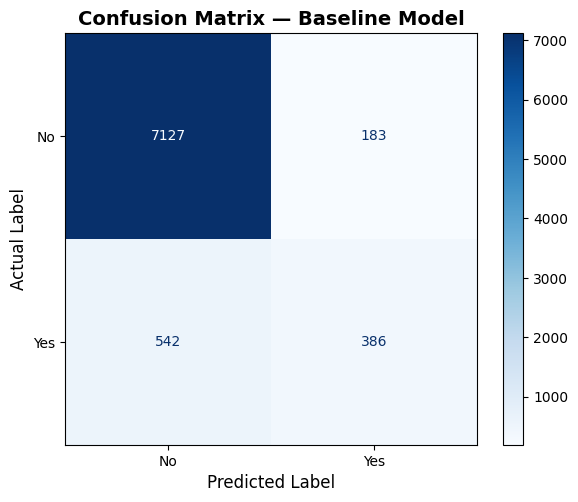

In [26]:
# Visualise the confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(cmap='Blues', ax=ax, values_format='d')

ax.set_title('Confusion Matrix — Baseline Model', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('Actual Label', fontsize=12)

plt.tight_layout()
plt.show()

### 5.2 Accuracy, Precision, Recall, F1-Score

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print('═' * 50)
print('        BASELINE MODEL METRICS')
print('═' * 50)
print(f'  Accuracy:   {accuracy:.4f}  — {accuracy:.1%} of all predictions correct')
print(f'  Precision:  {precision:.4f}  — {precision:.1%} of "subscribe" predictions were right')
print(f'  Recall:     {recall:.4f}  — {recall:.1%} of actual subscribers were caught')
print(f'  F1-Score:   {f1:.4f}  — Harmonic mean of precision and recall')
print('═' * 50)

══════════════════════════════════════════════════
        BASELINE MODEL METRICS
══════════════════════════════════════════════════
  Accuracy:   0.9120  — 91.2% of all predictions correct
  Precision:  0.6784  — 67.8% of "subscribe" predictions were right
  Recall:     0.4159  — 41.6% of actual subscribers were caught
  F1-Score:   0.5157  — Harmonic mean of precision and recall
══════════════════════════════════════════════════


**Interpreting these results:**
- **High accuracy** is misleading here — a model that always predicts "no" would get ~88% accuracy
- **Low recall** means we are missing many subscribers — the bank would lose potential customers
- **F1-Score** gives us a more balanced view of performance on the minority class

### 5.3 Classification Report

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['No Subscribe', 'Subscribe']))

              precision    recall  f1-score   support

No Subscribe       0.93      0.97      0.95      7310
   Subscribe       0.68      0.42      0.52       928

    accuracy                           0.91      8238
   macro avg       0.80      0.70      0.73      8238
weighted avg       0.90      0.91      0.90      8238



### 5.4 ROC Curve and AUC

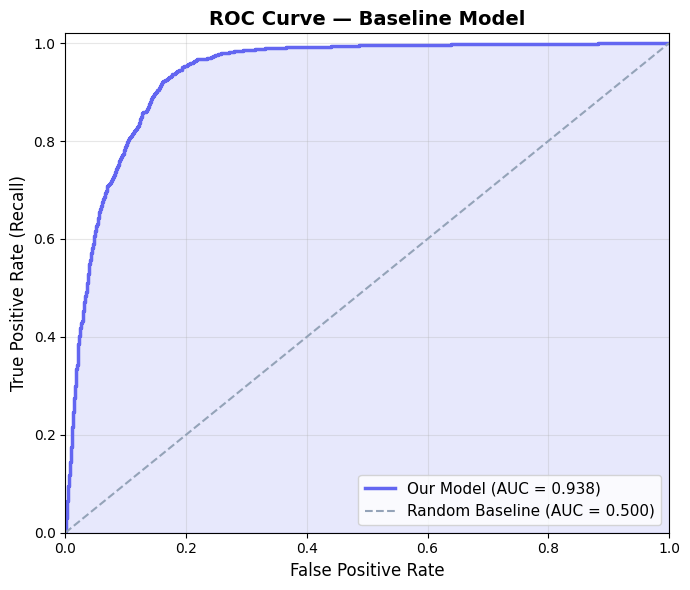

AUC-ROC Score: 0.9375
An AUC of 0.5 = random guessing, 1.0 = perfect classifier.


In [29]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

# Plot
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, color='#6366F1', linewidth=2.5, label=f'Our Model (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1], color='#94A3B8', linestyle='--', linewidth=1.5, label='Random Baseline (AUC = 0.500)')

ax.fill_between(fpr, tpr, alpha=0.15, color='#6366F1')

ax.set_title('ROC Curve — Baseline Model', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'AUC-ROC Score: {auc_score:.4f}')
print('An AUC of 0.5 = random guessing, 1.0 = perfect classifier.')

## 6. Hyperparameter Tuning with Grid Search

As we discussed in the lecture, the key hyperparameters for logistic regression are:

| Hyperparameter | What it controls | Values to try |
|---|---|---|
| **C** | Inverse regularisation strength | 0.01, 0.1, 1.0, 10 |
| **penalty** | Type of regularisation | L1 (Lasso), L2 (Ridge) |

We will use **GridSearchCV** with 5-fold cross-validation to find the best combination.

### 6.1 Define the Grid and Run the Search

In [30]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'C': [0.01, 0.1, 1.0, 10],
    'penalty': ['l1', 'l2'],
}

# Note: L1 requires solver='liblinear' or 'saga'
# We use 'liblinear' as it supports both L1 and L2
base_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)

# Run Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,
    scoring='f1',         # Use F1 because our data is imbalanced
    return_train_score=True,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f'\nGrid Search complete!')
print(f'  Total combinations tested: {len(grid_search.cv_results_["params"])}')
print(f'  Total fits: {len(grid_search.cv_results_["params"])} combos × 5 folds = {len(grid_search.cv_results_["params"]) * 5}')

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Grid Search complete!
  Total combinations tested: 8
  Total fits: 8 combos × 5 folds = 40


### 6.2 Examine the Results

In [ ]:
# View all results as a nice table
results = pd.DataFrame(grid_search.cv_results_)

# Select and rename the most useful columns
results_clean = results[['param_C', 'param_penalty', 'mean_test_score', 'std_test_score', 'mean_train_score', 'rank_test_score']]
results_clean.columns = ['C', 'Penalty', 'Mean CV F1', 'Std CV F1', 'Mean Train F1', 'Rank']
results_clean = results_clean.sort_values('Rank')

print('Grid Search Results (sorted by rank):')
print('=' * 70)
print(results_clean.to_string(index=False))

In [ ]:
# Visualise the grid search results
fig, ax = plt.subplots(figsize=(9, 5))

# Pivot the results for plotting
for penalty in ['l1', 'l2']:
    mask = results_clean['Penalty'] == penalty
    subset = results_clean[mask]
    colour = '#2D8CFF' if penalty == 'l2' else '#FF6B35'
    ax.plot(subset['C'].astype(str), subset['Mean CV F1'],
            marker='o', linewidth=2.5, markersize=9, label=f'{penalty.upper()} penalty', color=colour)
    # Add error bars
    ax.fill_between(range(len(subset)),
                    subset['Mean CV F1'].values - subset['Std CV F1'].values,
                    subset['Mean CV F1'].values + subset['Std CV F1'].values,
                    alpha=0.15, color=colour)

ax.set_xlabel('C (Regularisation Strength)', fontsize=12)
ax.set_ylabel('Mean F1-Score (5-Fold CV)', fontsize=12)
ax.set_title('Grid Search: F1-Score by C and Penalty Type', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.3 Best Hyperparameters

In [ ]:
print('═' * 50)
print('        BEST HYPERPARAMETERS')
print('═' * 50)
print(f'  Best C:       {grid_search.best_params_["C"]}')
print(f'  Best Penalty: {grid_search.best_params_["penalty"]}')
print(f'  Best F1 (CV): {grid_search.best_score_:.4f}')
print('═' * 50)

# The best model is already trained and accessible
best_model = grid_search.best_estimator_

### 6.4 Evaluate the Tuned Model on the Test Set

In [ ]:
# Predictions with the best model
y_pred_tuned = best_model.predict(X_test_scaled)
y_pred_proba_tuned = best_model.predict_proba(X_test_scaled)[:, 1]

accuracy_tuned  = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned    = recall_score(y_test, y_pred_tuned)
f1_tuned        = f1_score(y_test, y_pred_tuned)
auc_tuned       = roc_auc_score(y_test, y_pred_proba_tuned)

# Compare baseline vs tuned
print('═' * 60)
print('        BASELINE vs TUNED MODEL (Test Set)')
print('═' * 60)
print(f'{"Metric":<15} {"Baseline":>10} {"Tuned":>10} {"Change":>10}')
print('─' * 60)
print(f'{"Accuracy":<15} {accuracy:>10.4f} {accuracy_tuned:>10.4f} {accuracy_tuned - accuracy:>+10.4f}')
print(f'{"Precision":<15} {precision:>10.4f} {precision_tuned:>10.4f} {precision_tuned - precision:>+10.4f}')
print(f'{"Recall":<15} {recall:>10.4f} {recall_tuned:>10.4f} {recall_tuned - recall:>+10.4f}')
print(f'{"F1-Score":<15} {f1:>10.4f} {f1_tuned:>10.4f} {f1_tuned - f1:>+10.4f}')
print(f'{"AUC-ROC":<15} {auc_score:>10.4f} {auc_tuned:>10.4f} {auc_tuned - auc_score:>+10.4f}')
print('═' * 60)

## 7. Optimising the Decision Threshold

Remember from the lecture: the default threshold of **0.5** is not always optimal. By lowering it, we can catch more subscribers (↑ recall) at the cost of more false alarms (↓ precision).

Let's explore different thresholds and find the one that maximises our F1-Score.

In [ ]:
# Test a range of thresholds
thresholds_to_try = np.arange(0.1, 0.9, 0.05)

threshold_results = []

for t in thresholds_to_try:
    # Apply the threshold to probabilities
    y_pred_t = (y_pred_proba_tuned >= t).astype(int)

    # Compute metrics
    prec_t = precision_score(y_test, y_pred_t, zero_division=0)
    rec_t  = recall_score(y_test, y_pred_t)
    f1_t   = f1_score(y_test, y_pred_t)

    threshold_results.append({
        'Threshold': round(t, 2),
        'Precision': round(prec_t, 4),
        'Recall': round(rec_t, 4),
        'F1': round(f1_t, 4)
    })

threshold_df = pd.DataFrame(threshold_results)
print(threshold_df.to_string(index=False))

In [ ]:
# Visualise the precision-recall-F1 trade-off
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(threshold_df['Threshold'], threshold_df['Precision'],
        marker='s', linewidth=2, label='Precision', color='#0EA5E9')
ax.plot(threshold_df['Threshold'], threshold_df['Recall'],
        marker='^', linewidth=2, label='Recall', color='#FF6B35')
ax.plot(threshold_df['Threshold'], threshold_df['F1'],
        marker='o', linewidth=2.5, label='F1-Score', color='#2ECC71')

# Mark the best F1 threshold
best_idx = threshold_df['F1'].idxmax()
best_t = threshold_df.loc[best_idx, 'Threshold']
best_f1_val = threshold_df.loc[best_idx, 'F1']
ax.axvline(x=best_t, color='#2ECC71', linestyle='--', alpha=0.7)
ax.annotate(f'Best F1 = {best_f1_val:.3f}\nat threshold = {best_t}',
            xy=(best_t, best_f1_val), xytext=(best_t + 0.1, best_f1_val - 0.1),
            fontsize=11, fontweight='bold', color='#2ECC71',
            arrowprops=dict(arrowstyle='->', color='#2ECC71'))

# Mark default threshold
ax.axvline(x=0.5, color='#94A3B8', linestyle=':', alpha=0.8)
ax.text(0.51, 0.95, 'Default (0.5)', color='#94A3B8', fontsize=9, transform=ax.get_xaxis_transform())

ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision, Recall & F1-Score vs. Decision Threshold', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

### 7.1 Final Model with Optimised Threshold

In [ ]:
# Apply the best threshold
y_pred_final = (y_pred_proba_tuned >= best_t).astype(int)

accuracy_final  = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final)
recall_final    = recall_score(y_test, y_pred_final)
f1_final        = f1_score(y_test, y_pred_final)

print('═' * 70)
print('    BASELINE  vs  TUNED (C & penalty)  vs  TUNED + THRESHOLD')
print('═' * 70)
print(f'{"Metric":<15} {"Baseline":>12} {"+ GridSearch":>14} {"+ Threshold":>14}')
print('─' * 70)
print(f'{"Accuracy":<15} {accuracy:>12.4f} {accuracy_tuned:>14.4f} {accuracy_final:>14.4f}')
print(f'{"Precision":<15} {precision:>12.4f} {precision_tuned:>14.4f} {precision_final:>14.4f}')
print(f'{"Recall":<15} {recall:>12.4f} {recall_tuned:>14.4f} {recall_final:>14.4f}')
print(f'{"F1-Score":<15} {f1:>12.4f} {f1_tuned:>14.4f} {f1_final:>14.4f}')
print('═' * 70)
print(f'\nFinal model: C={grid_search.best_params_["C"]}, '
      f'penalty={grid_search.best_params_["penalty"]}, '
      f'threshold={best_t}')

In [ ]:
# Final confusion matrix
cm_final = confusion_matrix(y_test, y_pred_final)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Baseline
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes']).plot(cmap='Blues', ax=axes[0], values_format='d')
axes[0].set_title('Baseline (threshold=0.5)', fontsize=13, fontweight='bold')

# Final
ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=['No', 'Yes']).plot(cmap='Greens', ax=axes[1], values_format='d')
axes[1].set_title(f'Tuned (threshold={best_t})', fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrix: Before vs After Tuning', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Feature Importance

One advantage of logistic regression is **interpretability**. The model's weights tell us which features push the prediction towards "subscribe" (positive weight) or away from it (negative weight).

In [ ]:
# Extract and sort feature importances (coefficients)
coef_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': best_model.coef_[0]
})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)

# Plot top 15 features
top_features = coef_df.head(15)

fig, ax = plt.subplots(figsize=(9, 6))

colours = ['#2ECC71' if c > 0 else '#E74C3C' for c in top_features['Coefficient']]
ax.barh(range(len(top_features)), top_features['Coefficient'], color=colours, edgecolor='white')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'])
ax.invert_yaxis()

ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_title('Top 15 Feature Coefficients (Tuned Model)', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)

# Legend
ax.text(0.02, 0.98, '🟢 Positive = pushes towards "subscribe"\n🔴 Negative = pushes towards "no subscribe"',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

---

## Exercises

Now it's your turn! Complete the following exercises to consolidate your understanding.

---

### Exercise 1: Interpret the Confusion Matrix

Look at the **final tuned model's confusion matrix** above and answer the following questions in a text cell:

1. How many clients did the model **correctly identify** as subscribers?
2. How many clients were **wrongly flagged** as subscribers (false positives)?
3. How many actual subscribers did the model **miss** (false negatives)?
4. From a business perspective, which error is more costly for the bank — false positives or false negatives? Why?

In [ ]:
# Write your answers here as comments or in a text cell below

# 1.
# 2.
# 3.
# 4.


### Exercise 2: Manual Metric Calculation

Using the confusion matrix values from the **baseline model** (Section 5.1), manually calculate:
- Accuracy
- Precision
- Recall
- F1-Score

Then verify your answers using the variables we computed.

In [ ]:
# The confusion matrix values from the baseline model are:
print(f'TP = {TP}, TN = {TN}, FP = {FP}, FN = {FN}')
print()

# Calculate each metric manually (replace the ... with your formulas)
my_accuracy  = ...  # (TP + TN) / (TP + TN + FP + FN)
my_precision = ...  # TP / (TP + FP)
my_recall    = ...  # TP / (TP + FN)
my_f1        = ...  # 2 * (precision * recall) / (precision + recall)

# Uncomment to check your answers:
# print(f'My Accuracy:  {my_accuracy:.4f}  (scikit-learn: {accuracy:.4f})')
# print(f'My Precision: {my_precision:.4f}  (scikit-learn: {precision:.4f})')
# print(f'My Recall:    {my_recall:.4f}  (scikit-learn: {recall:.4f})')
# print(f'My F1:        {my_f1:.4f}  (scikit-learn: {f1:.4f})')

### Exercise 3: Expand the Grid Search

Our grid search was deliberately small. Try expanding it:

1. Add more values of `C` (e.g. `0.001`, `50`, `100`)
2. Change the scoring metric to `'recall'` instead of `'f1'`
3. Run the new grid search and compare the best parameters

**Question:** How do the best hyperparameters change when you optimise for recall instead of F1? Why?

In [ ]:
# Your expanded grid search here

# param_grid_expanded = {
#     'C': [...],           # Add more values
#     'penalty': ['l1', 'l2'],
# }

# grid_search_expanded = GridSearchCV(
#     estimator=LogisticRegression(solver='liblinear', random_state=42, max_iter=1000),
#     param_grid=param_grid_expanded,
#     cv=5,
#     scoring='recall',     # <-- Changed from 'f1'
#     verbose=1
# )

# grid_search_expanded.fit(X_train_scaled, y_train)
# print(f'Best params (recall): {grid_search_expanded.best_params_}')
# print(f'Best recall (CV):     {grid_search_expanded.best_score_:.4f}')

### Exercise 4: Threshold for Different Business Goals

Using the `y_pred_proba_tuned` probabilities, apply two different thresholds and compare the results:

- **Threshold = 0.3** (aggressive: catch as many subscribers as possible)
- **Threshold = 0.7** (conservative: only predict 'subscribe' when very confident)

For each, compute precision, recall, and F1-Score. Which threshold would you recommend to the bank, and why?

In [ ]:
# Threshold = 0.3
# y_pred_03 = (y_pred_proba_tuned >= 0.3).astype(int)
# print('Threshold = 0.3')
# print(f'  Precision: {precision_score(y_test, y_pred_03):.4f}')
# print(f'  Recall:    {recall_score(y_test, y_pred_03):.4f}')
# print(f'  F1-Score:  {f1_score(y_test, y_pred_03):.4f}')

# Threshold = 0.7
# y_pred_07 = (y_pred_proba_tuned >= 0.7).astype(int)
# print('\nThreshold = 0.7')
# print(f'  Precision: {precision_score(y_test, y_pred_07):.4f}')
# print(f'  Recall:    {recall_score(y_test, y_pred_07):.4f}')
# print(f'  F1-Score:  {f1_score(y_test, y_pred_07):.4f}')

# Your recommendation:
# ...

### Exercise 5: Feature Impact Analysis

Look at the feature importance chart in Section 8.

1. Identify the **top 3 features** that increase the probability of subscription.
2. Identify the **top 3 features** that decrease the probability of subscription.
3. If you were a marketing manager at the bank, how would you use these insights to improve the next campaign?

Write your answers in the cell below.

In [ ]:
# Write your answers here as comments

# 1. Top 3 features increasing subscription probability:
# 2. Top 3 features decreasing subscription probability:
# 3. Marketing recommendations:


---
**End of Notebook** — Great work! 🎉

You have now built a complete logistic regression pipeline: from raw data through preprocessing, modelling, evaluation, and hyperparameter tuning. The key takeaway is that **no single metric tells the whole story** — always consider the business context when choosing how to evaluate your model.